In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import ExtraTreesClassifier

In [2]:
np.random.seed(7)

class_0 = np.random.randn(200, 2) + np.array([2, 2])
class_1 = np.random.randn(200, 2) + np.array([6, 6])
class_2 = np.random.randn(200, 2) + np.array([4, 8])

X = np.vstack((class_0, class_1, class_2))

y = np.array(
    [0] * 200 +
    [1] * 200 +
    [2] * 200
)

print("Input data shape:", X.shape)
print("Target labels shape:", y.shape)

Input data shape: (600, 2)
Target labels shape: (600,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=5
)

In [4]:
parameter_grid = {
    'n_estimators': [25, 50, 100],
    'max_depth': [2, 4, 6],
    'min_samples_split': [2, 4, 6]
}

In [5]:
classifier = ExtraTreesClassifier(random_state=0)

In [6]:
grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=parameter_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=ExtraTreesClassifier(random_state=0),
             param_grid={'max_depth': [2, 4, 6], 'min_samples_split': [2, 4, 6],
                         'n_estimators': [25, 50, 100]},
             scoring='accuracy')

In [7]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [8]:
print("\nBest accuracy score:")
print(grid_search.best_score_)


Best accuracy score:
0.9511111111111111


In [9]:
best_classifier = grid_search.best_estimator_

best_classifier.fit(X_train, y_train)

ExtraTreesClassifier(max_depth=4, random_state=0)

In [10]:
y_test_pred = best_classifier.predict(X_test)

In [11]:
class_names = ['Class-0', 'Class-1', 'Class-2']

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     Class-0       1.00      1.00      1.00        44
     Class-1       0.94      0.98      0.96        51
     Class-2       0.98      0.95      0.96        55

    accuracy                           0.97       150
   macro avg       0.97      0.98      0.97       150
weighted avg       0.97      0.97      0.97       150



In [12]:
def visualize_classifier(classifier, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    step_size = 0.01
    x_values, y_values = np.meshgrid(
        np.arange(x_min, x_max, step_size),
        np.arange(y_min, y_max, step_size)
    )
    mesh_output = classifier.predict(
        np.c_[x_values.ravel(), y_values.ravel()]
    )
    mesh_output = mesh_output.reshape(x_values.shape)
    plt.figure()
    plt.pcolormesh(x_values, y_values, mesh_output, shading='auto')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

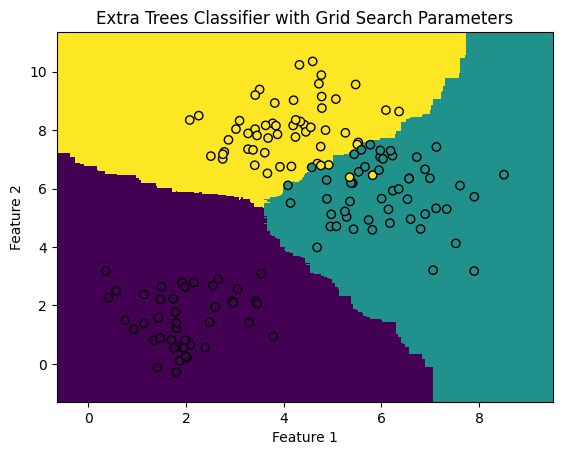

In [13]:
visualize_classifier(
    best_classifier,
    X_test,
    y_test,
    "Extra Trees Classifier with Grid Search Parameters"
)